In [1]:
import nci_ipynb
import os
nb_path = nci_ipynb.dir()
os.chdir(nb_path)

# Hands-on: Training a AIFS-Single with Anemoi

In this tutorial we will learn how to train a model like the AIFS-SINGLE model using the anemoi packages.

This will be done on a small subset of variables on a low resolution dataset so the model converges quickly to allow for rapid exploration.

**Learning Objectives**

By the end of this tutorial, you will:
- Understand the key differences between deterministic and ensemble CRPS training
- Learn how to configure the anemoi training pipeline for a "deterministic" model
- Build a minimal training configuration step-by-step
- Execute a short training run to verify everything works


**Resources**

- [Anemoi Documentation](https://anemoi.readthedocs.io/projects/training/en/latest/)
- [Moldovon et al. 2025](https://arxiv.org/abs/2509.18994v1)

## Background: What is the AIFS?

The AIFS Single has an encoder–processor–decoder structure, where the encoder first projects the model state onto a lower-resolution grid, using a graph neural network (GNN). The processor then uses a Transformer to update the model state 6‑hours in time before the decoder reprojects the model state back to the target resolution. Further details on the model structure can be found in Lang et al., 2024a (https://arxiv.org/abs/2406.01465). 

* The AIFS Single 1.0 was trained on ECMWF’s ERA5 reanalysis dataset (1979–2022) and then fine-tuned to the IFS operational analysis (2016–2022).




## Training in Anemoi

The main components of the training pipeline can be switched and modified in order to train other types of models, here we highlight the changes that will be done for the other notebook, for training of the ensemble model.

| Component | Deterministic | CRPS |
|-----------|---------------|------|
| **Forecaster** | `GraphForecaster` | `GraphEnsForecaster` |
| **Strategy** | `DDPGroupStrategy` | `DDPEnsGroupStrategy` |
| **Training Loss** | `WeightedMSELoss` | `AlmostFairKernelCRPS` |
| **Model** | `AnemoiModelEncProcDec` | `AnemoiEnsModelEncProcDec` |
| **Datamodule** | `AnemoiDatasetsDataModule` | `AnemoiEnsDatasetsDataModule` |


## Building Our Training Config

Now we'll examine our training configuration step-by-step. We have a minimal configuration file ready that we'll load and examine section by section.

In [2]:
# Let's start by importing the necessary modules
import yaml
from omegaconf import OmegaConf
from pathlib import Path

# Load our minimal configuration file
config_path = nb_path / Path("configs/aifs_single_minimal.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)


### Step 1: Hardware Configuration

The hardware configuration needs to specify the number of GPUs to use for training.

**Key Points:**
- `num_gpus_per_model`: Number of GPUs per model instance, used to shard the model if too big.

In [3]:
# Display the system configuration section
print("System Configuration:")
print("=" * 50)
print(yaml.dump(config['system'], default_flow_style=False))


System Configuration:
hardware:
  accelerator: auto
  num_gpus_per_model: 1
input:
  dataset: /g/data/dk92/data/anemoi/aifs-ea-an-oper-0001-mars-o48-2010-2022-6h-v1-toy.zarr
  graph: null
output:
  root: /scratch/${oc.env:PROJECT}/${oc.env:USER}/anemoi-output/



### Step 2: Model Configuration

Key model features for "deterministic" training are:

1. **Model Class**: Uses `AnemoiModelEncProcDec`

2. **Standard EncProcDec**: The model uses a standard encoder–processor–decoder structure, with configurable attention, and channel properties.

In [4]:
# Display the model configuration section
print("Model Configuration:")
print("=" * 30)
print(yaml.dump(config['model'], default_flow_style=False))


Model Configuration:
compile: []
condition_on_residual: false
decoder:
  graph_attention_backend: pyg
encoder:
  graph_attention_backend: pyg
model:
  _target_: anemoi.models.models.AnemoiModelEncProcDec
num_channels: 128
processor:
  _target_: anemoi.models.layers.processor.TransformerProcessor
  attention_implementation: scaled_dot_product_attention
  mlp_hidden_ratio: 4
  num_chunks: 4
  num_heads: 16
  num_layers: 8
  window_size: 512



## Step 3: Data configuraation

Now we configure the dataset, and loading parameters.

**Key Data Parameters:**

1. **batch_size**: Control how many batches are seen
2. **training.datasets**: Use anemoi-datasets to open and select the training data

In [5]:
# Display the model configuration section
print("Dataloader Configuration:")
print("=" * 30)
print(yaml.dump(config['dataloader'], default_flow_style=False))


Dataloader Configuration:
batch_size:
  training: 1
  validation: 1
limit_batches:
  training: 20
  validation: 10
training:
  datasets:
    data:
      dataset_config:
        dataset: ${dataloader.dataset}
        select:
        - z_1000
        - z_500
        - z_700
        - z_300
        - 2t
        - t_850
        - tcw
        - z_250
        - lsm
        - z
        - cp
        - tp
        - cos_latitude
        - cos_longitude
        - sin_latitude
        - sin_longitude
        - cos_julian_day
        - cos_local_time
        - sin_julian_day
        - sin_local_time
        - insolation
        - lsm
        - sdor
        - slor
        - z
      end: 2020
      start: null
validation:
  datasets:
    data:
      dataset_config: ${dataloader.training.datasets.data.dataset_config}
      end: 2021
      start: 2021



### Step 4: Training Configuration

Now we configure the training parameters, strategy, and loss function for training.

**Key Training Parameters:**

1. **Model Task**: Set to `GraphForecaster`
2. **Strategy**: Uses `DDPGroupStrategy` (standard data distributed parallel)
3. **Loss Function**: `MSELoss` with variable scalings


In [6]:
# Display the training configuration section
print("Training Configuration:")
print("=" * 30)
print(yaml.dump(config['training'], default_flow_style=False))


Training Configuration:
lr:
  iterations: ${training.max_steps}
  min: 3e-7
  rate: 1e-3
  warmup: 1000
max_steps: 200
model_task: anemoi.training.train.tasks.GraphForecaster
strategy:
  _target_: anemoi.training.distributed.strategy.DDPGroupStrategy
  num_gpus_per_model: ${system.hardware.num_gpus_per_model}
  read_group_size: ${dataloader.read_group_size}
training_loss:
  datasets:
    data:
      _target_: anemoi.training.losses.MSELoss
      ignore_nans: false
      scalers:
      - pressure_level
      - general_variable
      - node_weights
      - time_steps
validation_metrics:
  datasets:
    data:
      mse:
        _target_: anemoi.training.losses.MSELoss
        ignore_nans: true
        scalers:
        - node_weights
        - time_steps



## Training Execution

Now that we have our configuration ready, let's execute the training. We'll run a short training session to verify everything works correctly by running,

```bash
export ANEMOI_BASE_SEED=42
export ANEMOI_CONFIG_PATH="$PWD/configs"
anemoi-training train --config-name aifs_single_minimal
```

In [7]:
import subprocess
import sys, os 

# Set environment variables
os.environ['ANEMOI_BASE_SEED'] = '42'
os.environ['PBS_NGPUS'] = '1' # Set to 1 for single GPU training, adjust if using multiple GPUs
os.environ['PBS_NNODES'] = '1' # Set to 1 for single node training, adjust if using multiple nodes
os.environ['ANEMOI_CONFIG_PATH'] = str( nb_path / "configs")
os.environ['POSSIBLE_USER_WARNINGS'] = 'off'
os.environ['TORCH_LOGS'] = "-dynamo,-inductor"

# Execute the training using subprocess
print("Starting AIFS-SINGLE training...")
print("=" * 50)

process = subprocess.Popen(
    [
        "anemoi-training", "train", 
        "--config-name", "aifs_single_minimal.yaml"
    ], 
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,  # Merge stderr into stdout
    text=True,
    bufsize=1,  # Line buffered
    universal_newlines=True
)

# Stream output
for line in iter(process.stdout.readline, ''):
    if line:
        print(line.rstrip())  # Print immediately to Jupyter cell

# Wait for completion
return_code = process.wait()

print("=" * 50)
if return_code == 0:
    print("✓ Training completed successfully!")
else:
    print(f"❌ Training failed with return code {return_code}")

Starting AIFS-SINGLE training...
2026-04-15 11:19:06 INFO Running anemoi training command with overrides: ['--config-name', 'aifs_single_minimal.yaml']
2026-04-15 11:19:10 INFO Prepending Anemoi Config Env (/home/548/hc7988/.jupyter-root/home/Projects/ECMWF/training/2026-ml-bom-training/1-Anemoi/configs) to the search path.
2026-04-15 11:19:10 INFO Prepending current user directory (/home/548/hc7988/Projects/ECMWF/training/2026-ml-bom-training/1-Anemoi) to the search path.
2026-04-15 11:19:10 INFO Search path is now: [provider=anemoi-cwd-searchpath-plugin, path=/home/548/hc7988/Projects/ECMWF/training/2026-ml-bom-training/1-Anemoi, provider=anemoi-env-searchpath-plugin, path=/home/548/hc7988/.jupyter-root/home/Projects/ECMWF/training/2026-ml-bom-training/1-Anemoi/configs, provider=hydra, path=pkg://hydra.conf, provider=main, path=pkg://anemoi.training/config, provider=anemoi-package-searchpath-plugin, path=pkg://anemoi.training/config]
[2026-04-15 11:19:11,176][anemoi.training.schemas.

## Monitoring and Results

### MLflow logging

Several metrics and parameters are logged during training. Here, we use MLflow to log results offline. 

In the following we use the MLflow API to plot some key metrics during training, such as:

- **Training Loss**: The MSELoss loss should decrease over time
- **Validation Metrics**: Similar to training loss, calculated on validation data

*Note:* Typically the logging is done to a server and can be used interactively on a website.


## Server logging

Mlflow logs can be viewed in a web interface, below we skip this and directly retrieve, but if you want to do see it in that ui, move to the logging directory within this environment, and run `mlflow server`

```bash
cd /scratch/$PROJECT/$USER/anemoi-output/logs/mlflow
mlflow server
```

In [8]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt

run_id="8289585ba31342adaea04eeb9dfc1591" # CHANGE THIS TO YOUR RUN ID

# Start mlflow client and load run
client = mlflow.tracking.MlflowClient(tracking_uri=f"file:///scratch/{os.getenv('PROJECT')}/{os.getenv('USER')}/anemoi-output/logs/mlflow")
run = client.get_run(run_id)

print(f"Run name: {run.info.run_name}")
print("Logged metrics:")
print("=" * 50)
for k in run.data.metrics.keys():
    print(k)


Run name: 40a47bc5-1ad9-4b94-b73d-a5907ce1a1fe
Logged metrics:
val_multi_dataset_loss_step
val_data_mse_loss_scale_0
lr-AdamW
epoch
rollout
val_multi_dataset_loss_epoch
train_multi_dataset_loss_epoch
train_multi_dataset_loss_step
system/system_memory_total_megabytes
system/gpu_memory_total_megabytes
system/disk_usage_megabytes
system/gpu_0_power_usage_watts
system/system_memory_usage_megabytes
system/gpu_0_memory_usage_megabytes
system/cpu_utilization_percentage
system/disk_available_megabytes
system/gpu_0_pcie_tx_megabytes
system/gpu_0_utilization_percentage
system/disk_usage_percentage
system/network_transmit_megabytes
system/system_memory_usage_percentage
system/gpu_0_pcie_rx_megabytes
system/network_receive_megabytes
system/gpu_0_power_usage_percentage
system/gpu_0_memory_usage_percentage
val_data_mse_metric/data/sfc_tp/1_scale_0
val_data_mse_metric/data/t_850/1_scale_0
val_data_mse_metric/data/pl_t/1_scale_0
val_data_mse_metric/data/z_500/1_scale_0
val_data_mse_metric/data/all/1_s

Text(0, 0.5, 'loss')

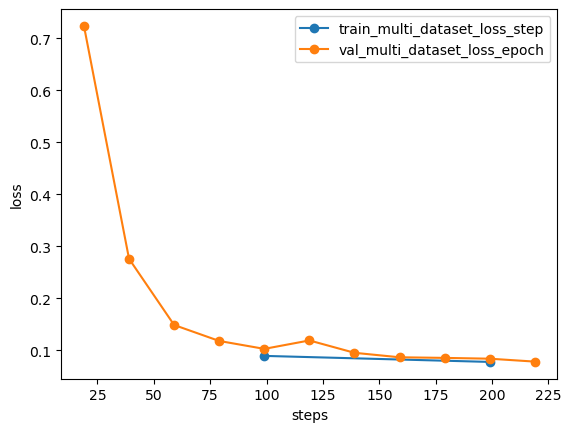

In [9]:
# Plotting 
metric_names = ['train_multi_dataset_loss_step', 'val_multi_dataset_loss_epoch']

# Load data into DataFrame
data = []
for metric in metric_names:
    for entry in client.get_metric_history(run_id, metric):
        data.append({'metric': metric, 'step': entry.step, 'value': entry.value, 'time': entry.timestamp})
df = pd.DataFrame(data)

# Plot all metrics
fig, ax = plt.subplots()
for metric in df['metric'].unique():
    metric_data = df[df['metric'] == metric].sort_values('step')
    ax.plot(metric_data['step'], metric_data['value'], '-o', label=metric)
ax.legend()
ax.set_xlabel('steps')
ax.set_ylabel('loss')


### Task 1: Alter the model

Adapt the training config and retrain the model with:
   - a larger number of channels, or chunks
   - train the model for longer by increasing the number of iterations (`max_steps`) and removing the batch limit

**Questions**
- How does your loss change with the same number of steps? 
- How much longer does the training take per iteration?
- What happens if you choose a large number of channels?

***Note***:

You do not need to do the training in the notebook. You can run on the console with: 
```
anemoi-training train --config-path PATH-TO-YOUR-CONFIG-FOLDER --config-name aifs_single_minimal_config
```

#### Task 1.1: Alter the config

Throughout the top level config, are various `ACTIVITY:` prompts which show parts you can easily modify to alter the training behaviour, explore these and design an experiment.


### Task 2: Inference of your model

Run inference on the model you have trained. For that, go back to the Jupyter notebook `../2-run-AIFS/inference_aifs-single.ipynb` and import your used checkpoint. 

***Note:***

You need to adapt, 
1. The resolution of the data for your input fields to O48

```
GRID_RESOLUTION = "O48"
PARAM_SFC = ['2t', 'tcw', "lsm", "z", "slor", "sdor"]
PARAM_PL = ['t', 'gh']
LEVELS = [1000, 850, 700, 500, 300, 250]
```

2. Select only the input fields you need, i.e. ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250', 'lsm', 'z', 'sdor', 'slor'] 


In case you were not able to train the checkpoint. You can find a checkpoint here:
`/g/data/dk92/data/anemoi/inference-single.ckpt`
